<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 03</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Denoising y objetivos de entrenamiento</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Pregunta directriz

> ¿Cómo se convierte el proceso directo de difusión en un problema de aprendizaje supervisado para entrenar un modelo de denoising?

El notebook anterior definió un proceso directo fijo: dado un dato limpio $x_0$, podemos construir una versión ruidosa $x_t$ para cualquier tiempo $t$. Esa construcción todavía no aprende nada. El paso nuevo consiste en usarla para fabricar ejemplos supervisados.

La pregunta central ya no es cómo agregar ruido, sino qué cantidad debe aprender a predecir un modelo cuando observa una imagen ruidosa $x_t$ y el tiempo $t$. Esta pregunta es el puente entre la formulación probabilística de la difusión directa y el entrenamiento de modelos de difusión.


## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Formular el problema de denoising inducido por el proceso directo de difusión.
2. Construir ejemplos supervisados de la forma $(x_t,t,\text{objetivo})$ usando la forma cerrada de $q(x_t \mid x_0)$.
3. Distinguir entre predecir $x_0$, predecir el ruido $\epsilon$ y aproximar una cantidad relacionada con el score.
4. Justificar por qué la predicción de ruido conduce a una pérdida cuadrática natural.
5. Reconstruir una estimación $\hat{x}_0$ a partir de $x_t$, $t$ y una predicción de ruido.
6. Analizar visualmente cómo los errores de predicción de ruido afectan la reconstrucción de la muestra limpia.


## Marco conceptual

El proceso directo define una familia de distribuciones condicionales $q(x_t \mid x_0)$. Para cada muestra limpia $x_0$ y cada tiempo $t$, podemos generar una muestra ruidosa $x_t$. Como durante la construcción conocemos el ruido exacto $\epsilon$ que fue usado, aparece una tarea supervisada natural: entregar al modelo la entrada ruidosa y pedirle que recupere la cantidad que produjo esa corrupción.

Esta idea es más fuerte de lo que parece. No necesitamos etiquetas humanas ni clases semánticas. La supervisión se obtiene de la propia ecuación de difusión directa. El dataset original proporciona $x_0$; el proceso directo proporciona $t$, $\epsilon$ y $x_t$.

Conviene distinguir dos niveles. En el nivel probabilístico, $q(x_t \mid x_0)$ describe cómo se corrompen los datos. En el nivel de aprendizaje, usamos esa corrupción conocida para construir una tarea: dado $(x_t,t)$, estimar una cantidad que permita deshacer la corrupción. La transición entre esos dos niveles es el núcleo del notebook.

El notebook no entrenará todavía una red neuronal. Antes de introducir arquitectura, embeddings temporales y optimización, debemos cerrar la formulación del objetivo de aprendizaje.


## Formulación matemática

Recordemos la forma cerrada del proceso directo:

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I).
$$

Esta ecuación permite generar triples supervisados

$$
(x_0,t,\epsilon) \longmapsto x_t.
$$

La notación anterior debe leerse con cuidado. El dato limpio $x_0$ viene del dataset; el tiempo $t$ lo elegimos; el ruido $\epsilon$ lo muestreamos; y $x_t$ se calcula. Por tanto, aunque el dataset original no tenga etiquetas, el procedimiento produce objetivos supervisados porque conocemos la variable aleatoria que agregamos.

Una vez construido $x_t$, podemos formular varias tareas de predicción.

La primera posibilidad es predecir directamente la muestra limpia:

$$
f_\theta(x_t,t) \approx x_0.
$$

Esta tarea es intuitiva: dado un dato ruidoso, recuperar la imagen limpia. Sin embargo, no es la única formulación posible ni necesariamente la más conveniente para difusión.

La segunda posibilidad es predecir el ruido usado en la corrupción:

$$
\epsilon_\theta(x_t,t) \approx \epsilon.
$$

Esta formulación parece menos natural al principio, porque el modelo aprende a predecir ruido en lugar de imágenes. Su ventaja es que el objetivo $\epsilon$ tiene una distribución conocida, centrada y común para todos los datos. Además, si el ruido se predice bien, la imagen limpia puede recuperarse algebraicamente.

La tercera posibilidad, más cercana a la formulación por score, es estimar una dirección proporcional al gradiente logarítmico de la distribución condicional. Para la gaussiana condicional anterior se tiene

$$
\nabla_{x_t}\log q(x_t \mid x_0)
=
-
\frac{x_t-\sqrt{\bar{\alpha}_t}\,x_0}{1-\bar{\alpha}_t}
=
-
\frac{\epsilon}{\sqrt{1-\bar{\alpha}_t}}.
$$

Esta ecuación explica por qué la predicción de ruido no es un truco desconectado de la teoría. Bajo la forma cerrada, el ruido determina la dirección del score condicional salvo un factor dependiente del tiempo.

Hay un matiz importante. La ecuación anterior usa $q(x_t \mid x_0)$ porque durante la construcción conocemos el dato limpio que originó la muestra ruidosa. Un modelo de difusión, en cambio, recibe solo $(x_t,t)$; no recibe $x_0$. Al promediar sobre los posibles datos limpios compatibles con $x_t$, el objetivo de predicción de ruido se conecta con el score marginal de la distribución ruidosa $q_t(x_t)$:

$$
\nabla_{x_t}\log q_t(x_t)
=
-\frac{1}{\sqrt{1-\bar{\alpha}_t}}
\mathbb{E}[\epsilon \mid x_t,t].
$$

Esta relación anticipa la lectura por score que estudiaremos más adelante. En este notebook no desarrollaremos todavía modelos basados en score; solo usaremos esta conexión para entender por qué $\epsilon$ es un objetivo matemáticamente significativo.

Nos concentraremos en la predicción de ruido, porque conduce a un objetivo computacional directo:

$$
\mathcal{L}(\theta)
=
\mathbb{E}_{x_0,t,\epsilon}
\left[
\left\|
\epsilon - \epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

La esperanza indica cómo se construye el entrenamiento: se promedian errores sobre datos limpios, tiempos de difusión y muestras de ruido. En la práctica, esta esperanza se aproxima con mini-lotes.

Si tenemos una predicción de ruido, también podemos despejar una estimación de la imagen limpia:

$$
\hat{x}_0
=
\frac{x_t-\sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta(x_t,t)}
{\sqrt{\bar{\alpha}_t}}.
$$

Por tanto, predecir ruido no es una tarea artificial. Es una forma de aprender la información necesaria para invertir el proceso directo.


<div style="text-align: center; margin: 18px 0 8px 0;">
  <img src="../assets/figures/formulacion_objetivo_denoising.png" alt="Formulación del objetivo de denoising" style="width: 100%; max-width: 1100px;">
</div>


La figura resume el cambio de perspectiva. El proceso directo genera una entrada ruidosa $x_t$ a partir de $x_0$ y $\epsilon$. El modelo recibe $(x_t,t)$ y aprende a aproximar el ruido verdadero. Esa predicción permite definir una pérdida cuadrática y también reconstruir una estimación $\hat{x}_0$.

La lectura importante es que $\epsilon$ cumple dos papeles. Durante el proceso directo, es la perturbación que destruye estructura. Durante el entrenamiento, se convierte en la señal supervisada que el modelo debe recuperar. Esta inversión de roles es una de las ideas que hacen que los modelos de difusión sean entrenables.


## Preparación del entorno

Usaremos el subconjunto de QuickDraw ya preparado. El objetivo es construir ejemplos de entrenamiento y analizar el comportamiento de las cantidades involucradas, no entrenar todavía un modelo neuronal.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_house_50k_28x28.npz"

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"

RNG = np.random.default_rng(20260418)
DATASET_PATH


## Dataset y normalización

Como en el notebook anterior, normalizamos las imágenes desde $[0,1]$ hacia $[-1,1]$. Esta escala permite combinar datos y ruido gaussiano en la ecuación cerrada sin introducir desplazamientos innecesarios.


In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Verifica que esta distribucion incluya data/quickdraw/processed/quickdraw_house_50k_28x28.npz"
    )

with np.load(DATASET_PATH) as data:
    x_train_uint8 = data["x_train"]
    class_names = data["class_names"]

x_01 = x_train_uint8.astype(np.float32) / 255.0
x_data = 2.0 * x_01 - 1.0
n, h, w = x_data.shape
d = h * w

print(f"Clase: {class_names[0]}")
print(f"Imágenes: {x_data.shape}")
print(f"Rango normalizado: [{x_data.min():.1f}, {x_data.max():.1f}]")
print(f"Dimensión vectorial: d = {d}")


Clase: house
Imágenes: (45000, 28, 28)
Rango normalizado: [-1.0, 1.0]
Dimensión vectorial: d = 784


## Agenda de ruido

Mantenemos la misma agenda lineal del notebook 02. Esto permite comparar directamente la degradación visual, la SNR y los ejemplos supervisados que construiremos aquí.

En este notebook la agenda cumple además otro papel: define la dificultad de cada ejemplo de entrenamiento. Un tiempo pequeño produce una entrada cercana a $x_0$; un tiempo grande produce una entrada dominada por ruido. Por eso el mismo modelo deberá aprender a resolver una familia de problemas de denoising, no un único nivel de corrupción.


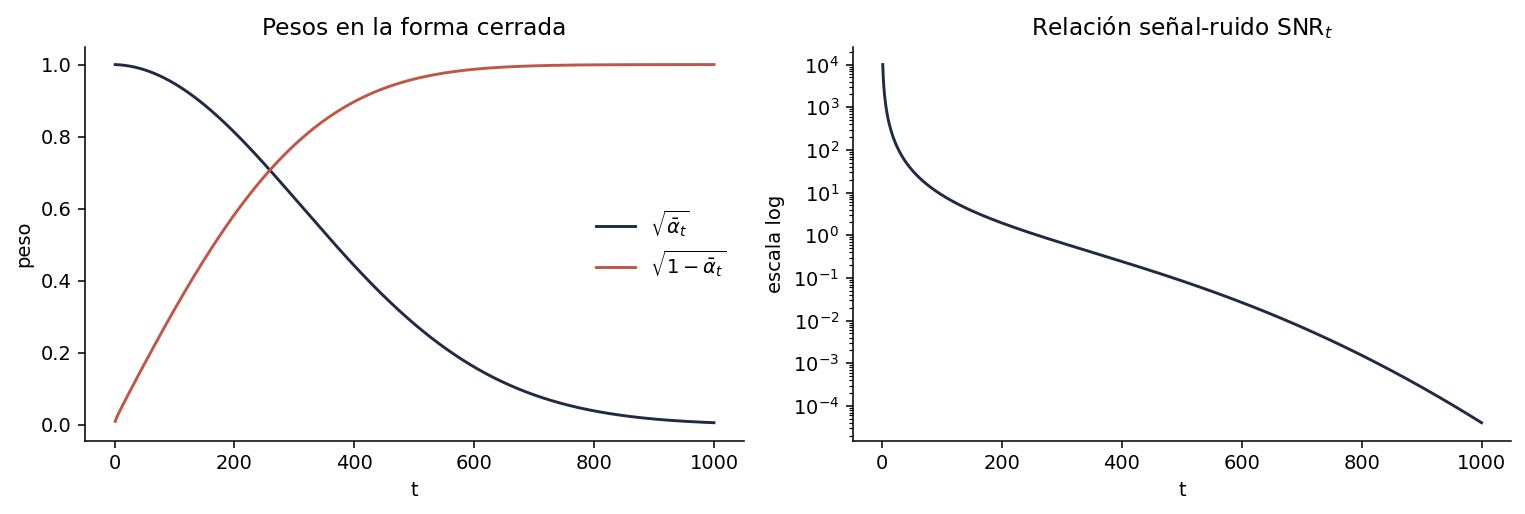

In [3]:
T = 1000
beta_inicio = 1e-4
beta_fin = 2e-2

betas = np.linspace(beta_inicio, beta_fin, T, dtype=np.float64)
alphas = 1.0 - betas
alpha_bars = np.cumprod(alphas)
timesteps = np.arange(1, T + 1)

signal_weight = np.sqrt(alpha_bars)
noise_weight = np.sqrt(1.0 - alpha_bars)
snr = alpha_bars / np.maximum(1.0 - alpha_bars, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(timesteps, signal_weight, label=r"$\sqrt{\bar{\alpha}_t}$", color="#1f2a44")
axes[0].plot(timesteps, noise_weight, label=r"$\sqrt{1-\bar{\alpha}_t}$", color="#c05746")
axes[0].set_title("Pesos en la forma cerrada")
axes[0].set_xlabel("t")
axes[0].set_ylabel("peso")
axes[0].legend(frameon=False)

axes[1].plot(timesteps, snr, color="#1f2a44")
axes[1].set_yscale("log")
axes[1].set_title(r"Relación señal-ruido $\mathrm{SNR}_t$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("escala log")
fig.tight_layout()


## Funciones de muestreo y reconstrucción

La función `q_sample` genera $x_t$ y conserva el ruido $\epsilon$ usado. Esa segunda salida es fundamental: en el notebook 03 el ruido deja de ser solo una perturbación y se convierte en el objetivo supervisado.

La función `reconstruct_x0_from_epsilon` implementa el despeje algebraico de $x_0$. Su propósito no es simular un modelo real, sino mostrar qué sería posible si la predicción $\epsilon_\theta(x_t,t)$ fuera exacta o aproximadamente correcta.


In [4]:
def q_sample(x0, t_index, alpha_bars, rng):
    """Sample x_t from q(x_t | x_0) and return the noise used."""
    alpha_bar_t = alpha_bars[t_index]
    eps = rng.normal(size=x0.shape).astype(np.float32)
    xt = np.sqrt(alpha_bar_t) * x0 + np.sqrt(1.0 - alpha_bar_t) * eps
    return xt.astype(np.float32), eps


def reconstruct_x0_from_epsilon(xt, eps_pred, t_index, alpha_bars):
    """Recover x_0 estimate from a predicted epsilon."""
    alpha_bar_t = alpha_bars[t_index]
    x0_hat = (xt - np.sqrt(1.0 - alpha_bar_t) * eps_pred) / np.sqrt(alpha_bar_t)
    return x0_hat.astype(np.float32)


def to_image_range(x):
    return np.clip((x + 1.0) / 2.0, 0.0, 1.0)


def noise_to_image(eps, clip=3.0):
    return np.clip((eps + clip) / (2.0 * clip), 0.0, 1.0)


def show_data_image(ax, image, title):
    ax.imshow(to_image_range(image), vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")


def show_noise_image(ax, eps, title):
    ax.imshow(noise_to_image(eps), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")


## Construcción de ejemplos supervisados

Para cada muestra limpia $x_0$, elegimos un tiempo $t$ y generamos ruido $\epsilon$. La entrada supervisada será $(x_t,t)$ y el objetivo será $\epsilon$. En símbolos:

$$
x_0 \sim p_{\mathrm{data}},
\qquad
 t \sim \mathrm{Uniform}\{1,\ldots,T\},
\qquad
\epsilon \sim \mathcal{N}(0,I),
$$

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon.
$$

El tiempo se toma aleatoriamente para que el modelo no aprenda a resolver solo una intensidad de ruido. Cada muestra del dataset puede generar muchos ejemplos supervisados distintos, porque podemos variar $t$ y $\epsilon$.

En la siguiente visualización se usa el mismo $x_0$ para varios tiempos. La fila superior se repite deliberadamente: muestra que a partir de un único dato limpio pueden construirse muchas entradas ruidosas distintas y muchos objetivos de ruido asociados.


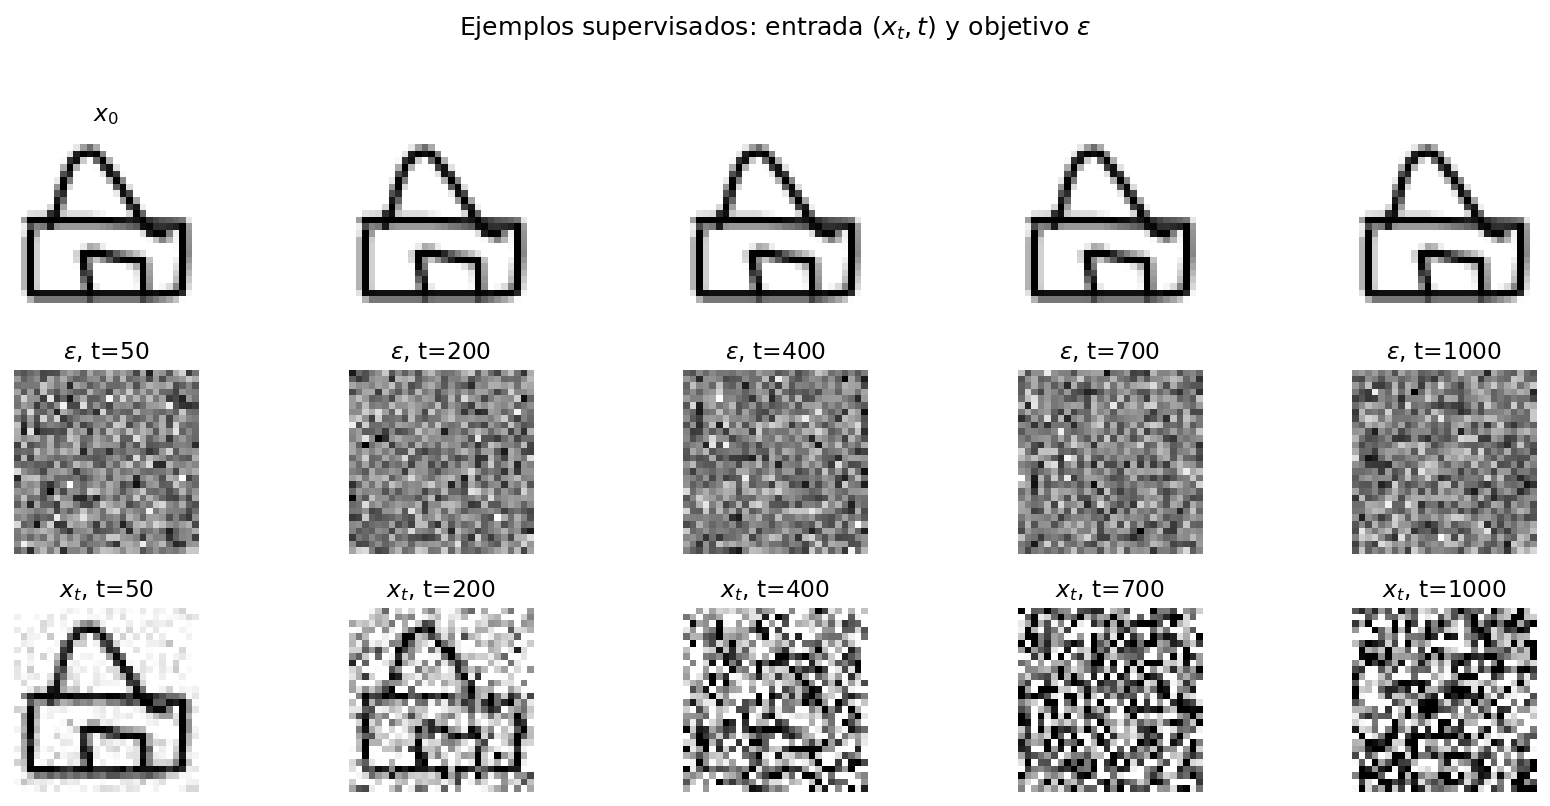

In [5]:
x0 = x_data[0]
selected_t = [49, 199, 399, 699, 999]

fig, axes = plt.subplots(3, len(selected_t), figsize=(12.5, 5.6))
for col, t_index in enumerate(selected_t):
    xt, eps = q_sample(x0, t_index, alpha_bars, RNG)
    show_data_image(axes[0, col], x0, r"$x_0$" if col == 0 else "")
    show_noise_image(axes[1, col], eps, rf"$\epsilon$, t={t_index + 1}")
    show_data_image(axes[2, col], xt, rf"$x_t$, t={t_index + 1}")

axes[0, 0].set_ylabel("dato", fontsize=11)
axes[1, 0].set_ylabel("objetivo", fontsize=11)
axes[2, 0].set_ylabel("entrada", fontsize=11)
fig.suptitle(r"Ejemplos supervisados: entrada $(x_t,t)$ y objetivo $\epsilon$", y=1.02, fontsize=13)
fig.tight_layout()


## Reconstrucción ideal

Si conocemos el ruido verdadero $\epsilon$, podemos reconstruir exactamente $x_0$ salvo errores numéricos. Esta operación no es todavía aprendizaje; es una comprobación algebraica de que la predicción de ruido contiene la información necesaria para estimar la muestra limpia.

La reconstrucción ideal también aclara una confusión frecuente: el objetivo no es producir ruido como resultado final. El objetivo es aprender una cantidad que permita retirar de $x_t$ la parte atribuible al ruido.


MSE de reconstrucción con el ruido verdadero:
t=  50 | MSE=1.380e-15
t= 200 | MSE=2.116e-15
t= 400 | MSE=5.581e-15
t= 700 | MSE=8.217e-14
t=1000 | MSE=1.729e-11


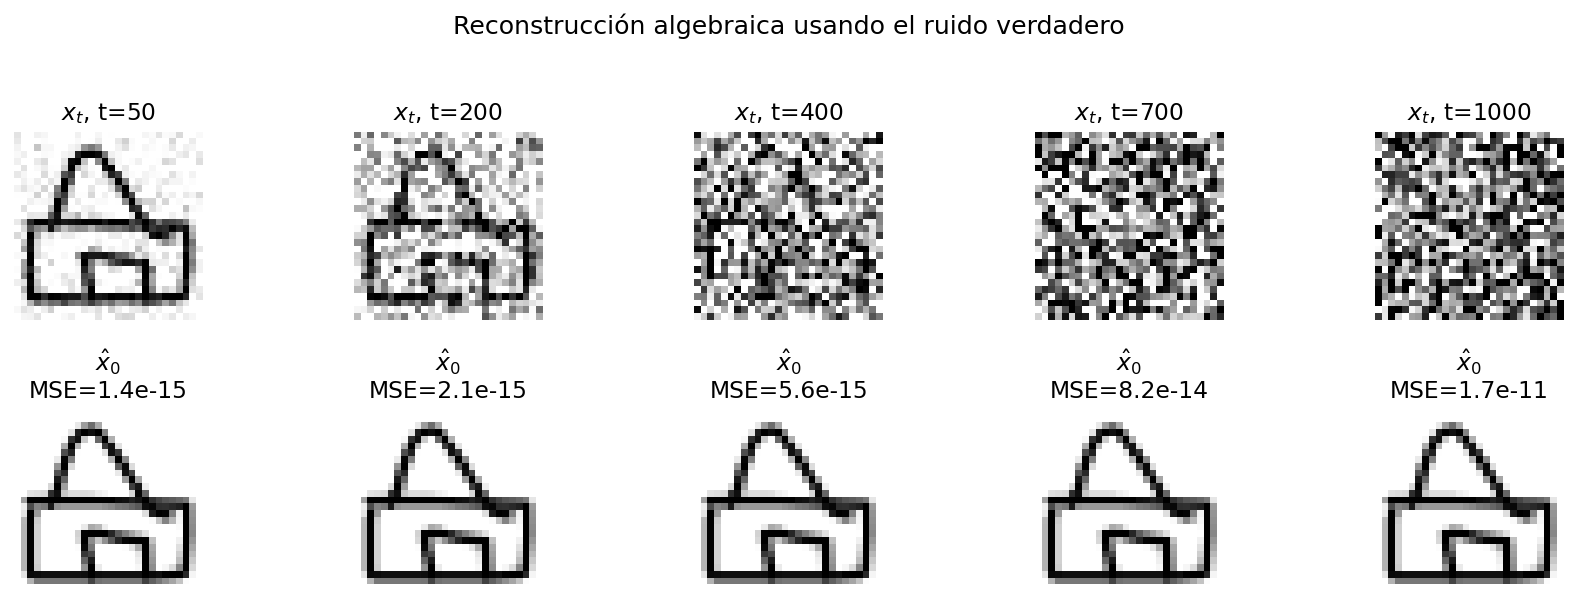

In [6]:
selected_t = [49, 199, 399, 699, 999]
fig, axes = plt.subplots(2, len(selected_t), figsize=(12.5, 4.2))

mse_values = []
for col, t_index in enumerate(selected_t):
    xt, eps = q_sample(x0, t_index, alpha_bars, RNG)
    x0_hat = reconstruct_x0_from_epsilon(xt, eps, t_index, alpha_bars)
    mse = np.mean((x0_hat - x0) ** 2)
    mse_values.append(mse)

    show_data_image(axes[0, col], xt, rf"$x_t$, t={t_index + 1}")
    show_data_image(axes[1, col], x0_hat, f"$\\hat{{x}}_0$\nMSE={mse:.1e}")

fig.suptitle("Reconstrucción algebraica usando el ruido verdadero", y=1.03, fontsize=13)
fig.tight_layout()

print("MSE de reconstrucción con el ruido verdadero:")
for t_index, mse in zip(selected_t, mse_values):
    print(f"t={t_index + 1:4d} | MSE={mse:.3e}")


## Error de predicción de ruido

En entrenamiento real no conocemos $\epsilon_\theta(x_t,t)$ de antemano; el modelo lo aproxima. Si la predicción de ruido tiene error

$$
\delta_t = \epsilon_\theta(x_t,t)-\epsilon,
$$

entonces la reconstrucción inducida satisface

$$
\hat{x}_0 - x_0
=
-
\sqrt{\frac{1-\bar{\alpha}_t}{\bar{\alpha}_t}}\,\delta_t.
$$

Esto muestra que el mismo error de predicción de ruido no afecta igual en todos los tiempos. Cuando $\bar{\alpha}_t$ es pequeño, el factor de amplificación puede ser grande.

La ecuación no debe interpretarse como una razón para evitar tiempos grandes. Los tiempos grandes son necesarios porque conectan los datos con ruido gaussiano. La consecuencia es que el modelo debe estar condicionado por $t$ y el entrenamiento debe exponerlo a distintos niveles de ruido.


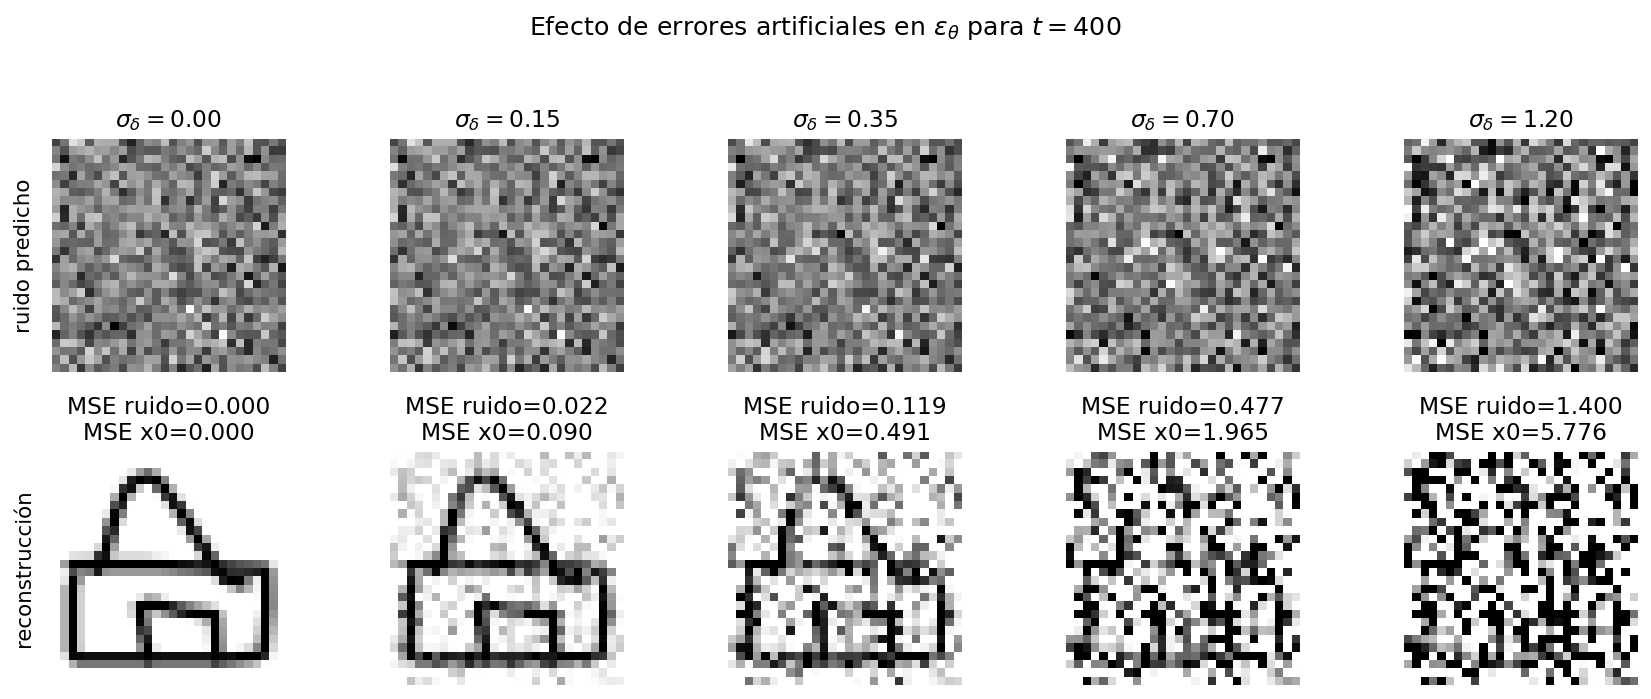

In [7]:
t_index = 399
xt, eps = q_sample(x0, t_index, alpha_bars, RNG)
error_scales = [0.0, 0.15, 0.35, 0.70, 1.20]
eta = RNG.normal(size=x0.shape).astype(np.float32)

fig, axes = plt.subplots(2, len(error_scales), figsize=(12.5, 4.8))
for col, scale in enumerate(error_scales):
    eps_pred = eps + scale * eta
    x0_hat = reconstruct_x0_from_epsilon(xt, eps_pred, t_index, alpha_bars)
    mse_eps = np.mean((eps - eps_pred) ** 2)
    mse_x0 = np.mean((x0 - x0_hat) ** 2)

    show_noise_image(axes[0, col], eps_pred, rf"$\sigma_\delta={scale:.2f}$")
    show_data_image(axes[1, col], x0_hat, f"MSE ruido={mse_eps:.3f}\nMSE x0={mse_x0:.3f}")

axes[0, 0].text(-0.12, 0.5, "ruido predicho", transform=axes[0, 0].transAxes, rotation=90, ha="center", va="center", fontsize=11)
axes[1, 0].text(-0.12, 0.5, "reconstrucción", transform=axes[1, 0].transAxes, rotation=90, ha="center", va="center", fontsize=11)
fig.suptitle(rf"Efecto de errores artificiales en $\epsilon_\theta$ para $t={t_index + 1}$", y=1.03, fontsize=13)
fig.tight_layout()


## Amplificación temporal del error

La ecuación anterior produce un factor determinista:

$$
A_t
=
\sqrt{\frac{1-\bar{\alpha}_t}{\bar{\alpha}_t}}.
$$

Este factor no depende de la imagen ni del modelo; depende solamente de la agenda de ruido. Por eso el tiempo $t$ debe entregarse al modelo: la tarea de denoising cambia de dificultad a lo largo de la cadena.

Cuando $A_t$ es pequeño, un error en la predicción de ruido tiene poco efecto sobre la reconstrucción de $x_0$. Cuando $A_t$ es grande, pequeñas desviaciones en $\epsilon_\theta$ pueden traducirse en reconstrucciones muy degradadas. Esta observación anticipa por qué el entrenamiento y el muestreo de modelos de difusión deben tratar cuidadosamente la dependencia temporal.


t=  50 | alpha_bar=0.971016 | A_t=0.173
t= 200 | alpha_bar=0.659039 | A_t=0.719
t= 400 | alpha_bar=0.195146 | A_t=2.031
t= 700 | alpha_bar=0.006966 | A_t=11.940
t=1000 | alpha_bar=0.000040 | A_t=157.407


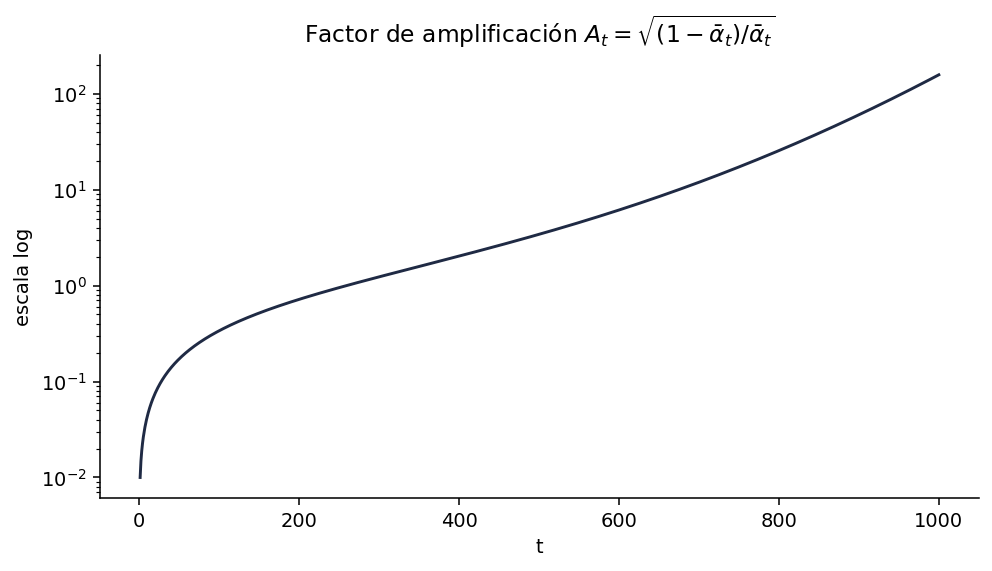

In [8]:
amplification = np.sqrt((1.0 - alpha_bars) / np.maximum(alpha_bars, 1e-12))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(timesteps, amplification, color="#1f2a44")
ax.set_yscale("log")
ax.set_title(r"Factor de amplificación $A_t = \sqrt{(1-\bar{\alpha}_t)/\bar{\alpha}_t}$")
ax.set_xlabel("t")
ax.set_ylabel("escala log")
fig.tight_layout()

for t_index in [49, 199, 399, 699, 999]:
    print(f"t={t_index + 1:4d} | alpha_bar={alpha_bars[t_index]:.6f} | A_t={amplification[t_index]:.3f}")


## Mini-lote sintético

Un lote de entrenamiento para predicción de ruido puede construirse sin etiquetas externas. Para cada imagen del lote, elegimos un tiempo aleatorio y generamos su ruido. El modelo verá imágenes con niveles de corrupción distintos y deberá usar el tiempo $t$ para interpretar la escala de la tarea.

La fila superior representa las entradas del modelo, $(x_t,t)$. La fila inferior representa los objetivos supervisados, $\epsilon$. Esta figura no muestra predicciones porque todavía no hemos definido una red neuronal.

Este mini-lote es la unidad conceptual del entrenamiento DDPM simplificado: datos limpios, tiempos aleatorios, ruido gaussiano, entradas ruidosas y objetivo de ruido. En el siguiente notebook reemplazaremos la palabra ``modelo'' por una red concreta.


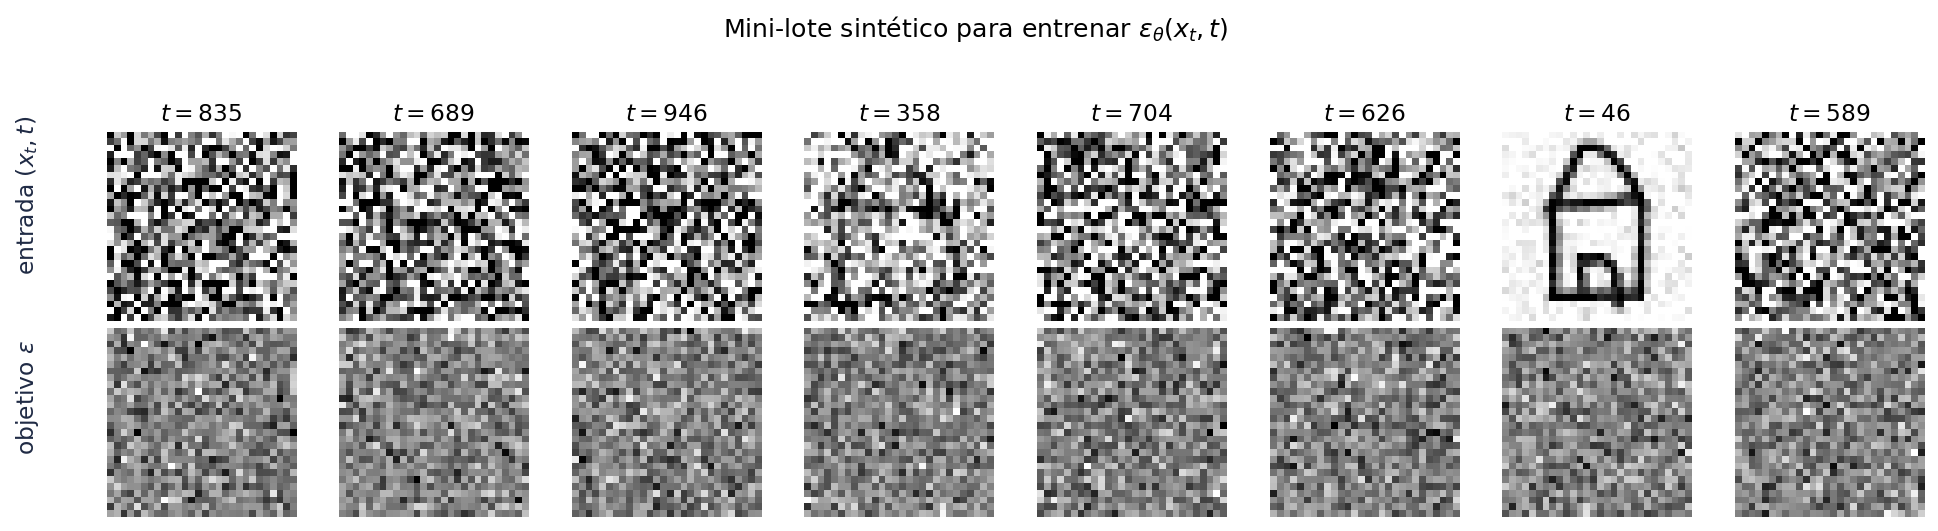

In [9]:
batch_size = 8
indices = RNG.choice(n, size=batch_size, replace=False)
t_indices = RNG.integers(0, T, size=batch_size)

fig, axes = plt.subplots(2, batch_size, figsize=(14, 3.6))
for col, (idx, t_index) in enumerate(zip(indices, t_indices)):
    x0_b = x_data[idx]
    xt_b, eps_b = q_sample(x0_b, int(t_index), alpha_bars, RNG)
    show_data_image(axes[0, col], xt_b, rf"$t={int(t_index) + 1}$")
    show_noise_image(axes[1, col], eps_b, "")

fig.text(0.016, 0.68, r"entrada $(x_t,t)$", rotation=90, ha="center", va="center", fontsize=12, color="#1f2a44")
fig.text(0.016, 0.28, r"objetivo $\epsilon$", rotation=90, ha="center", va="center", fontsize=12, color="#1f2a44")
fig.suptitle(r"Mini-lote sintético para entrenar $\epsilon_\theta(x_t,t)$", y=1.04, fontsize=13)
fig.tight_layout(rect=[0.04, 0, 1, 1])


## Qué se aprende y qué queda pendiente

En este notebook no se ajusta ningún parámetro. Lo que queda definido es el problema de aprendizaje. El modelo futuro recibirá una entrada ruidosa $x_t$ y una representación del tiempo $t$, y producirá una estimación $\epsilon_\theta(x_t,t)$.

La pérdida cuadrática compara esa predicción con el ruido verdadero usado por el proceso directo. En forma práctica, un paso de entrenamiento tendrá esta estructura:

$$
x_0 \rightarrow t,\epsilon \rightarrow x_t \rightarrow \epsilon_\theta(x_t,t) \rightarrow
\left\|\epsilon-\epsilon_\theta(x_t,t)\right\|_2^2.
$$

Esta cadena resume el paso conceptual del curso: ya no estamos únicamente describiendo cómo se corrompen los datos; ahora tenemos una tarea optimizable. Lo que todavía falta es introducir una familia de funciones capaz de representar $\epsilon_\theta$. Ese será el papel de una red neuronal condicionada por tiempo.


## Síntesis

**Resultado conceptual.** La difusión directa convierte un dataset no etiquetado en un problema supervisado. A partir de $x_0$, un tiempo $t$ y ruido gaussiano $\epsilon$, construimos $x_t$ mediante

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon.
$$

El objetivo de predicción de ruido entrena un modelo para aproximar

$$
\epsilon_\theta(x_t,t) \approx \epsilon,
$$

usando la pérdida

$$
\mathcal{L}(\theta)
=
\mathbb{E}
\left[
\left\|
\epsilon-\epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

La predicción de ruido es útil porque permite despejar una estimación de $x_0$ y porque está conectada con el score condicional de la distribución gaussiana del proceso directo. Esta formulación prepara el primer entrenamiento real de un modelo de difusión: ya sabemos qué entrada recibe el modelo, qué debe predecir y cómo medir su error.


## Preguntas de discusión

1. ¿Por qué el proceso directo permite construir supervisión sin etiquetas humanas?
2. ¿Qué diferencia conceptual hay entre predecir $x_0$ y predecir $\epsilon$?
3. ¿Cómo se obtiene $\hat{x}_0$ a partir de una predicción de ruido?
4. ¿Por qué el tiempo $t$ debe entregarse como entrada al modelo?
5. ¿Qué relación existe entre predicción de ruido y score condicional?
6. ¿Por qué el mismo error en $\epsilon_\theta$ puede afectar más la reconstrucción en tiempos grandes?
7. ¿Qué parte de esta formulación todavía no especifica una arquitectura neuronal?


## Continuidad

El siguiente notebook introducirá una red neuronal compacta para representar $\epsilon_\theta(x_t,t)$. Allí aparecerán los elementos de entrenamiento que deliberadamente dejamos fuera de este notebook: arquitectura, embedding temporal, optimizador, bucle de entrenamiento y evaluación cualitativa de muestras generadas desde ruido.
